In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
feature_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeFeatures" #to store features
os.makedirs(feature_dir, exist_ok=True)

In [ ]:

folder_path = '/content/drive/MyDrive/RandomForestResults'

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")


Folder '/content/drive/MyDrive/RandomForestResults' created successfully.


In [ ]:
!pip install scikit-image==0.19.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 105.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 111.5 MB/s eta 0:00:00
  Created wheel for scikit-image: filename=scikit_image-0.19.3-cp311-cp311-linux_x86_64.whl size=33913057 sha256=e4f1cc9946cb5189df021e5def8e84064393a7eb394a7f09152721d03c43e684
  Stored in directory: /root/.cache/pip/wheels/7b/12/cd/f311cabf9e8708d1e29e9951ee0839fb89b69e1acc60c94927
Successfully built scikit-image
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2


In [ ]:
!pip install -U scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 132.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.19.3
    Uninstalling scikit-image-0.19.3:
      Successfully uninstalled scikit-image-0.19.3


In [ ]:

from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [ ]:

dataset_path = '/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive'

# Create the train, valid, and test folders
for folder_name in ['train', 'valid', 'test']:
    folder_path = os.path.join(dataset_path, folder_name)
    os.makedirs(folder_path, exist_ok=True)


In [ ]:

import os
import shutil
import random

# Set random seed for reproducibility
random.seed(42)

# Base paths
base_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive"
data_dir = os.path.join(base_dir, "data")

# Destination folders
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

# Create destination folders if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# List all images in the data folder
all_images = [f for f in os.listdir(data_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(all_images)

# Split ratios
train_ratio = 0.8
valid_ratio = 0.1
test_ratio = 0.1

n_total = len(all_images)
n_train = int(train_ratio * n_total)
n_valid = int(valid_ratio * n_total)

# Split the data
train_imgs = all_images[:n_train]
valid_imgs = all_images[n_train:n_train + n_valid]
test_imgs  = all_images[n_train + n_valid:]

# Copy function
def copy_images(images, dest_dir):
    for img_name in images:
        src = os.path.join(data_dir, img_name)
        dst = os.path.join(dest_dir, img_name)
        shutil.copy2(src, dst)

# Perform the copy
copy_images(train_imgs, train_dir)
copy_images(valid_imgs, valid_dir)
copy_images(test_imgs,  test_dir)

print("✅ Split complete:")
print(f"Train: {len(train_imgs)} images")
print(f"Valid: {len(valid_imgs)} images")
print(f"Test:  {len(test_imgs)} images")


✅ Split complete:
Train: 115 images
Valid: 14 images
Test:  15 images


In [ ]:
from PIL import ImageEnhance, ImageOps
import os
from glob import glob
from PIL import Image
import numpy as np
import random

#augmentation function
def augment_image(image):
    aug_images = []

    # Horizontal Flip
    aug_images.append(ImageOps.mirror(image))

    # Vertical Flip
    aug_images.append(ImageOps.flip(image))

    # Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    aug_images.append(enhancer.enhance(1.2))
    aug_images.append(enhancer.enhance(0.8))

    # Contrast Adjustment
    enhancer = ImageEnhance.Contrast(image)
    aug_images.append(enhancer.enhance(1.2))
    aug_images.append(enhancer.enhance(0.8))

    # Rotation (small angles)
    for angle in [-10, 10, -15, 15]:
        aug_images.append(image.rotate(angle))

    return aug_images

# Run Augmentation
input_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive/train"
output_dir = input_dir  # Save in the same folder

image_paths = glob(os.path.join(input_dir, "*.jpg"))

for img_path in image_paths:
    img = Image.open(img_path)
    basename = os.path.basename(img_path).split('.')[0]

    augmented = augment_image(img)

    for i, aug_img in enumerate(augmented):
        save_path = os.path.join(output_dir, f"{basename}_aug{i}.jpg")
        aug_img.save(save_path)


In [ ]:
import os
import re
import pandas as pd

# Correct base paths
base_path = "/content/drive/MyDrive/TradionalOlives/oliveTreeNewDataset/DatasetOlive"
output_dir = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Dataset splits
splits = ["train", "valid", "test"]

# Regex: extract numeric yield like "55kg", "90k", " 34 kg"
def extract_yield_from_filename(filename):
    match = re.search(r'(\d+)\s*k(?:g)?', filename.lower())
    return float(match.group(1)) if match else None

# Process each split
for split in splits:
    image_dir = os.path.join(base_path, split)
    data = []

    for filename in os.listdir(image_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            yield_val = extract_yield_from_filename(filename)
            if yield_val is not None:
                full_path = os.path.join(image_dir, filename)
                data.append({
                    "image_path": full_path,
                    "yield_kg": float(yield_val)
                })

    # Save CSV
    df = pd.DataFrame(data)
    df['yield_kg'] = df['yield_kg'].astype('float32')
    output_csv = os.path.join(output_dir, f"{split}_realdata.csv")
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved {split} CSV to: {output_csv} | Total samples: {len(df)}")


✅ Saved train CSV to: /content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/train_realdata.csv | Total samples: 1265
✅ Saved valid CSV to: /content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/valid_realdata.csv | Total samples: 14
✅ Saved test CSV to: /content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/test_realdata.csv | Total samples: 15


In [ ]:
# Define paths

# Images folder paths (for feature extraction)
train_img_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/train"
valid_img_dir = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/valid"
test_img_dir  = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/PreparedData/test"

# CSV ground truth paths
train_csv = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/train_realdata.csv"
valid_csv = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/valid_realdata.csv"
test_csv  = "/content/drive/MyDrive/OliveTreeFinalCNNsegmentation/RealYieldCSVs/test_realdata.csv"

In [ ]:
#  Read them into DataFrames
train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df  = pd.read_csv(test_csv)

# Visual check
print("Train set:")
print(train_df.head())

print("\nValidation set:")
print(valid_df.head())

print("\nTest set:")
print(test_df.head())

Train set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...     190.0
1  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      60.0
2  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      85.0
3  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...     225.0
4  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      90.0

Validation set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      50.0
1  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      84.0
2  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      50.0
3  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      70.0
4  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      50.0

Test set:
                                          image_path  yield_kg
0  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      78.0
1  /content/drive/MyDrive/OliveTreeFinalCNNsegmen...      60.0
2  /content/driv

In [ ]:
#  GLCM feature extractor function
def extract_glcm_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) #Loads the image from the provided path in grayscale mode using OpenCV
    if img is None:
        return None
    img = cv2.resize(img, (224, 224)) #Resizes the grayscale image to 224×224 pixels
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True) #Computes the Gray-Level Co-occurrence Matrix (GLCM) for the image
    #distances=[1]: Check neighboring pixels that are 1 pixel apart
    #angles=[0]: Only consider the horizontal direction (0°)
    #levels=256: Assumes 8-bit images (pixel values 0–255)
    #symmetric=True: Symmetrizes the matrix (makes it more robust)
    #normed=True: Normalize so the GLCM becomes a probability matrix
    return [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ]
    #contrast: Measures intensity difference between a pixel and its neighbor
    #dissimilarity: Similar to contrast but less sensitive to large differences
    #homogeneity: High when pixel values are similar (uniform textures)
    #energy: Measures textural uniformity (higher = more regular texture)
    #correlation: Measures linear dependency of neighboring pixel intensities

In [ ]:
feature_dir ="/content/drive/MyDrive/TradionalOlives/oliveTreeFeatures"

In [ ]:
# Dataset processing function
def process_dataset(csv_path, split_name):
    df = pd.read_csv(csv_path)
    features, labels = [], []

    print(f"🔍 Processing {split_name}...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        feats = extract_glcm_features(row['image_path'])
        if feats:
            features.append(feats)
            labels.append(row['yield_kg'])

    features_df = pd.DataFrame(features, columns=['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation'])
    features_df['yield_kg'] = labels
    features_df.to_csv(os.path.join(feature_dir, f"{split_name}_features.csv"), index=False)
    return np.array(features), np.array(labels)

In [ ]:
# Extract features
X_train, y_train = process_dataset(train_csv, "train")
X_valid, y_valid = process_dataset(valid_csv, "valid")
X_test,  y_test  = process_dataset(test_csv, "test")

🔍 Processing train...


100%|██████████| 1265/1265 [00:10<00:00, 117.20it/s]


🔍 Processing valid...


100%|██████████| 14/14 [00:00<00:00, 98.91it/s]


🔍 Processing test...


100%|██████████| 15/15 [00:00<00:00, 117.70it/s]


In [ ]:
# Build ML pipeline
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])


In [ ]:
# Train on training set
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [ ]:
def evaluate(y_true, y_pred, title=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # ✅ Manual square root instead of squared=False
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📈 {title} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R2  : {r2:.2f}")


In [ ]:

# Validation performance
valid_preds = model_pipeline.predict(X_valid)
evaluate(y_valid, valid_preds, "Validation Set")



📈 Validation Set Performance:
RMSE: 17.78
MAE : 15.45
R2  : -0.25


In [ ]:
# Test performance
test_preds = model_pipeline.predict(X_test)
evaluate(y_test, test_preds, "Test Set")


📈 Test Set Performance:
RMSE: 24.93
MAE : 18.31
R2  : -0.93


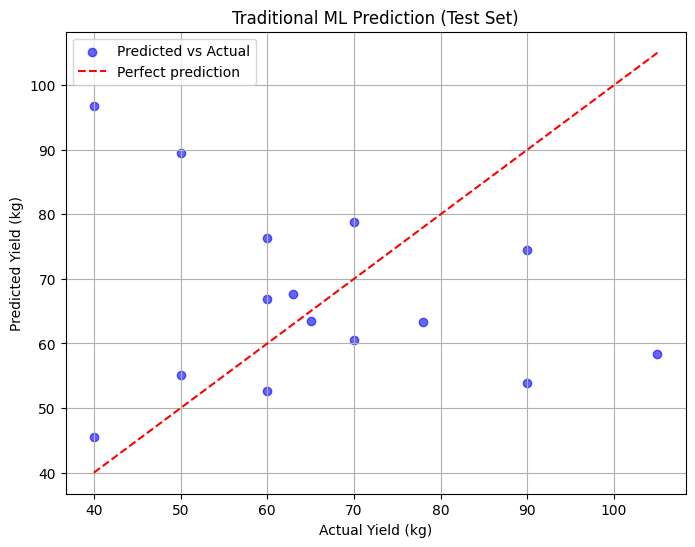

In [ ]:
# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, c='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Perfect prediction')
plt.xlabel('Actual Yield (kg)')
plt.ylabel('Predicted Yield (kg)')
plt.title('Traditional ML Prediction (Test Set)')
plt.legend()
plt.grid(True)



In [ ]:
import pandas as pd

# Create DataFrame from your predictions
comparison_df = pd.DataFrame({
    'Real_Yield_kg': y_test,
    'Predicted_Yield_kg': test_preds
})

# Optional: Round values for cleaner display
comparison_df['Real_Yield_kg'] = comparison_df['Real_Yield_kg'].round(2)
comparison_df['Predicted_Yield_kg'] = comparison_df['Predicted_Yield_kg'].round(2)

# Show the table
print("📊 Real vs Predicted Yield (kg):")
print(comparison_df.head(50))  # Show first 10 rows



📊 Real vs Predicted Yield (kg):
    Real_Yield_kg  Predicted_Yield_kg
0            78.0               63.27
1            60.0               66.96
2            65.0               63.50
3           105.0               58.44
4            60.0               76.31
5            50.0               55.08
6            70.0               78.76
7            63.0               67.65
8            90.0               74.51
9            50.0               89.45
10           70.0               60.61
11           60.0               52.68
12           40.0               96.77
13           40.0               45.50
14           90.0               53.84
